In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import scipy.stats as sts
from sklearn.feature_selection import f_regression
import scipy.stats
from scipy.stats import normaltest, jarque_bera
import numpy as np
from scipy import stats

In [2]:
gamma = 0.91
alpha = 0.09

1. Найдите оценки параметров линейной регрессионной модели   зависимости ЗАРПЛАТЫ от Z.															

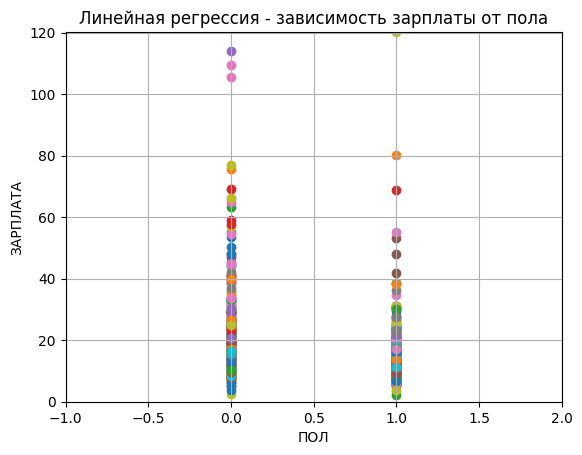

Смещение:  23.114481440297777
Наклон:  -6.9565184345970374
Зарплата (уравнение линейной регрессии) = 23 + -7 * пол


In [4]:
df = pd.read_excel('C:/Users/User/Downloads/LAB_4_DATA_2023.xlsx')
selected_columns = df.iloc[:, :4]

# Определение переменных Y и Z 
Z = selected_columns['ПОЛ (1-жен, 0- муж)'].values.reshape(-1, 1)
Y = selected_columns['Зарплата (долл. в час)'].values

# Настраиваем график
axes = plt.axes()
axes.set_xlim([-1, 2])
axes.set_ylim([0, max(Y)])
plt.title('Линейная регрессия - зависимость зарплаты от пола')
x_label = 'ПОЛ'
y_label = 'ЗАРПЛАТА'
axes.set_xlabel(x_label)
axes.set_ylabel(y_label)

# Устанавливаем точки на графике
for i in range(len(Z)):
    plt.scatter(Z[i], Y[i])
plt.grid()
plt.show()

model = LinearRegression()
model.fit(Z, Y)


b_0_hat = model.intercept_
b_1_hat = model.coef_[0]
print('Смещение: ', b_0_hat)
print('Наклон: ', b_1_hat)

print(f'Зарплата (уравнение линейной регрессии) = {round(b_0_hat)} + {round(b_1_hat)} * пол')

1.1. Проверьте, обладает ли модель высокой объясняющей способностью, или же модель низкого качества (Для этого примените F-тест)																					

In [5]:
# F-тест для проверки модели(cравнивает дисперсии отношение дисперсий между выборками к дисперсии внутры выборки)
#f_statistic, p_value = f_regression(Z, Y)

##print("F-статистика:", f_statistic[0])
#print("p-value:", p_value[0])
    
# Проверка значимости p-значения 
#if p_value[0] > alpha:
#    print("Модель обладает статтистически не значимой объясняющей способностью")
#else:
#    print("Модель обладает статистически значимой объясняющей способностью")
#
#print('Коэффициент детерминации:', model.score(Z, Y))

In [6]:
z_test = model.predict(Z)
ess_list = []
rss_list = []

for yi, yi_predicted in zip(Y, z_test):
    ess_list.append((yi - yi_predicted)**2)
    rss_list.append((yi_predicted - np.mean(Y))**2)
    
ess = sum(ess_list)
rss = sum(rss_list)
print('Коэффициент детерминации:', model.score(Z, Y))

F = rss*(len(Y)-1-1)/(1*ess)
#F_crit = sts.f.ppf(1-alpha, 1, len(Y)-1-1)
p_value = 1 - scipy.stats.f.cdf(F, 1, len(Y)-1 -1)
print(f'Результаты F-теста: {F}, p-value:{p_value}')
if(p_value < alpha):
    print('Модель обладает высокой объясняющей способностью\n')
else:
    print('Модель не обладает высокой объясняющей способностью\n')

Коэффициент детерминации: 0.058325699504434114
Результаты F-теста: 33.32280207378673, p-value:1.3200009085778674e-08
Модель обладает высокой объясняющей способностью



Проверка на нормальность регрессии

In [7]:
errors = []
for i in range(len(Y)):
    errors.append(Y[i] - (b_0_hat + b_1_hat * Z[i][0]))

rez_jarque_bera = jarque_bera(errors)  
print(f'Тест Джарка-Бера: {rez_jarque_bera}') # определяет, имеют ли выборочные данные асимметрию и эксцесс, соответствующие нормальному распределению.

if(rez_jarque_bera[1] > alpha):
    print('Регрессия имеет нормальное распределение\n')
else:
    print('Регрессия не имеет нормального распределения\n')

rez_normaltest = normaltest(errors)
print(f'Тест Д\'Агустино: {rez_normaltest}') # Тест предполагает сначала, что данные имеют норм распределение, 
#и проверяет насколько  коэф ассиметрии и эксцесса соответсвуют теор значениям для нормального распределения
if(rez_jarque_bera[1] > alpha):
    print('Регрессия имеет нормальное распределение\n')
else:
    print('Регрессия не имеет нормального распределения\n')

Тест Джарка-Бера: Jarque_beraResult(statistic=5688.74782558085, pvalue=0.0)
Регрессия не имеет нормального распределения

Тест Д'Агустино: NormaltestResult(statistic=390.9015117083931, pvalue=1.3086251081447052e-85)
Регрессия не имеет нормального распределения



2. Найдите оценки параметров линейной регрессионной модели   зависимости ЗАРПЛАТЫ от СТАЖА РАБОТЫ, ВРЕМЕНИ, ЗАТРАЧЕННОГО НА ОБРАЗОВАНИЕ, и ПОЛА РАБОТНИКА работника.																														

In [8]:
columns_all = df.iloc[:, 0:4]

Z_2 = columns_all[['СТАЖ РАБОТЫ (лет)', 'ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)', 'ПОЛ (1-жен, 0- муж)']].values 
Y_2 = np.array(columns_all['Зарплата (долл. в час)'])  
Y_2 = Y_2.reshape((-1, 1))

model_2 = LinearRegression()
model_2.fit(Z_2, Y_2)

b_0_hat = model_2.intercept_[0]
b_1_hat = model_2.coef_[0]


print(f'Зарплата = {b_0_hat:.2f} + {b_1_hat[0]:.2f} * Стаж работы + {b_1_hat[1]:.2f} * Время на обучение + {b_1_hat[2]:.2f} * Пол')


Зарплата = -19.69 + 0.41 * Стаж работы + 2.59 * Время на обучение + -5.91 * Пол


ПРОВЕРКА НА НОРМАЛЬНОСТЬ ОСТАТКОВ РЕГРЕССИИ

In [9]:
x1 = np.array(columns_all['СТАЖ РАБОТЫ (лет)'])
x2 = np.array(columns_all['ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)'])
x3 = np.array(columns_all['ПОЛ (1-жен, 0- муж)'])
    
errors = []
for i in range(len(Y_2)):
    errors.append(Y_2[i][0] - (b_0_hat + b_1_hat[0] * x1[i] + b_1_hat[1] * x2[i] + b_1_hat[2] * x3[i]))

result_jarque_bera = stats.jarque_bera(errors)
print('\nТест Джара-Бэра:', result_jarque_bera)
    
if result_jarque_bera[1] > alpha:
    print('\nОстатки регрессии имеют нормальное распределение (H0 - верна)')
else:
    print('\nОстатки регрессии распределены не по нормальному закону (H0 - неверна)')

result_normaltest = stats.normaltest(errors)
print('\nТест Д\'Агостино:', result_normaltest)

if result_normaltest[1] > alpha:
    print('\nОстатки регрессии  имеют нормальное распределение')
else:
    print('\nОстатки регрессии, согласно Д\'Агостино, распределены не по нормальному закону')


Тест Джара-Бэра: Jarque_beraResult(statistic=7226.888780316278, pvalue=0.0)

Остатки регрессии распределены не по нормальному закону (H0 - неверна)

Тест Д'Агостино: NormaltestResult(statistic=404.7522546494346, pvalue=1.2857739834288093e-88)

Остатки регрессии, согласно Д'Агостино, распределены не по нормальному закону


2.1. Как в среднем изменится ЗАРПЛАТА, если СТАЖ РАБОТЫ увеличится на 2 года?													

In [10]:
Z_2[:, 0] += 2
avg_y0 = np.average(Y_2)
avg_y1 = np.average(model_2.predict(Z_2))
print('Среднее увеличение ЗАРПЛАТЫ, при увеличении СТАЖА РАБОТЫ на 2 года:', avg_y1 - avg_y0, '(долл. в час)')
Z_2[:, 0] -= 2

Среднее увеличение ЗАРПЛАТЫ, при увеличении СТАЖА РАБОТЫ на 2 года: 0.8113543980273548 (долл. в час)


2.2. Какую в среднем прибавку к ЗАРПЛАТЕ  дает дополнительный год обучения?												

In [93]:
Z_2[:, 1] += 1
avg_y0 = np.average(Y_2)
avg_y1 = np.average(model_2.predict(Z_2))
print('Среднее увеличение ЗАРПЛАТЫ, при увеличении ВРЕМЕНИ, ЗАТРАЧЕННОГО НА ОБРАЗОВАНИЕ на 1 год:', avg_y1 - avg_y0, '(долл. в час)')
Z_2[:, 1] -= 1

Среднее увеличение ЗАРПЛАТЫ, при увеличении ВРЕМЕНИ, ЗАТРАЧЕННОГО НА ОБРАЗОВАНИЕ на 1 год: 2.591137323674417 (долл. в час)


2.3. Проверьте, обладает ли модель из п.3. высокой объясняющей способностью, или же модель низкого качества (Для этого примените F-тест)																						

In [187]:
f_statistic_, p_value_ = f_regression(Z_2, Y_2)
print(f'F-статистика: {f_statistic_[0]}')
print(f'p_value: {p_value_[0]}')
if p_value_[0] < alpha:
    print(f'Модель обладает статистически значимой объясняющей способностью.')
else:
    print(f'Модель не обладает статистически значимой объясняющей способностью.')

print('\nКоэффициент детерминации:', model_2.score(Z_2, Y_2))

F-статистика: 2.98343217208089
p_value: 0.0846946525128349
Модель обладает статистически значимой объясняющей способностью.

Коэффициент детерминации: 0.24084836762729878


c:\Users\User\Python project\.venv\lib\site-packages\sklearn\utils\validation.py:1141: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [10]:
Z_test = model_2.predict(Z_2)
ess_list = []
rss_list = []

for yi, z_predicted in zip(Y_2, Z_test):
    ess_list.append((yi - z_predicted)**2)
    rss_list.append((z_predicted - np.mean(Y))**2)
    
ess = sum(ess_list)
rss = sum(rss_list)
R_siq = model_2.score(Z_2, Y)
print('\nКоэффициент детерминации: ', R_siq)

F = (rss/3)/(ess/(len(Y)-3-1))
p_value = 1 - scipy.stats.f.cdf(F, 3, len(Y)-3 -1)
print(f'Результаты F-теста: {F[0]}, p-value:{p_value}')
if(p_value < alpha):
    print('Модель обладает высокой объясняющей способностью\n')
else:
    print('Модель не обладает высокой объясняющей способностью\n')

print(F)


Коэффициент детерминации:  0.24084836762729878
[1.11022302e-16]
Результаты F-теста: 56.683768012964336 Fкрит:2.1749376985618647
Модель обладает высокой объясняющей способностью

56.68376801296432


2.4. Значимо ли различаются зарплаты мужчины и женщины при прочих равных условиях (т.е. равных стаже и числу лет, затраченных на образование) ?																								

In [105]:
Z_3 = sm.add_constant(Z_2) 
model_sm = sm.OLS(Y_2, Z_3).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     56.68
Date:                Sat, 23 Dec 2023   Prob (F-statistic):           7.74e-32
Time:                        14:22:26   Log-Likelihood:                -2132.2
No. Observations:                 540   AIC:                             4272.
Df Residuals:                     536   BIC:                             4290.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -19.6919      4.361     -4.516      0.0

2.5.  Можно ли считать, что при начислении зарплаты  имеет место дискриминация по гендерному признаку?																	

Вполне